In [1]:
# ─── Cellule 1 : Imports et chargement ────────────────────────────
import pandas as pd
import numpy as np
import os, sys, joblib
sys.path.append(os.path.join(os.getcwd(), "..", "src"))
from utils.config import DATA_PROCESSED, MODELS_DIR

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(os.path.join(DATA_PROCESSED, "crimes_features.csv"))

# Features utilisées pour le modèle
FEATURES = [
    "heure", "jour_semaine", "mois", "trimestre",
    "est_weekend", "est_nuit", "gravite",
    "densite_district", "densite_area",
    "crime_type_code", "location_code",
    "District", "Community Area", "Beat"
]
CIBLE = "niveau_risque"

# Nettoyer les NaN
df_model = df[FEATURES + [CIBLE]].dropna()
X = df_model[FEATURES]
y = df_model[CIBLE]

print(f"✅ Données prêtes : {len(df_model):,} lignes | {len(FEATURES)} features")
print(f"   Distribution cible :")
print(f"   🟢 Faible (0) : {(y==0).sum():>8,} ({(y==0).mean()*100:.1f}%)")
print(f"   🟠 Moyen  (1) : {(y==1).sum():>8,} ({(y==1).mean()*100:.1f}%)")
print(f"   🔴 Élevé  (2) : {(y==2).sum():>8,} ({(y==2).mean()*100:.1f}%)")

✅ Données prêtes : 597,038 lignes | 14 features
   Distribution cible :
   🟢 Faible (0) :   95,962 (16.1%)
   🟠 Moyen  (1) :  433,883 (72.7%)
   🔴 Élevé  (2) :   67,193 (11.3%)


In [2]:
# ─── Cellule 2 : Entraînement Random Forest ───────────────────────
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"✅ Split effectué :")
print(f"   Train : {len(X_train):,} lignes")
print(f"   Test  : {len(X_test):,} lignes")

# Entraînement
print("\n⏳ Entraînement Random Forest en cours...")
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print("✅ Random Forest entraîné !")

# Évaluation
y_pred_rf = rf.predict(X_test)
print("\n📊 Rapport de classification :")
print(classification_report(y_test, y_pred_rf,
      target_names=["Faible", "Moyen", "Élevé"]))

✅ Split effectué :
   Train : 477,630 lignes
   Test  : 119,408 lignes

⏳ Entraînement Random Forest en cours...
✅ Random Forest entraîné !

📊 Rapport de classification :
              precision    recall  f1-score   support

      Faible       1.00      1.00      1.00     19192
       Moyen       1.00      1.00      1.00     86777
       Élevé       1.00      1.00      1.00     13439

    accuracy                           1.00    119408
   macro avg       1.00      1.00      1.00    119408
weighted avg       1.00      1.00      1.00    119408



In [3]:
# ─── Cellule 3 : Correction data leakage ─────────────────────────

# Features SANS les densités calculées sur tout le dataset
FEATURES_CORRIGEES = [
    "heure", "jour_semaine", "mois", "trimestre",
    "est_weekend", "est_nuit", "gravite",
    "crime_type_code", "location_code",
    "District", "Community Area", "Beat"
]

df_model2 = df[FEATURES_CORRIGEES + [CIBLE]].dropna()
X2 = df_model2[FEATURES_CORRIGEES]
y2 = df_model2[CIBLE]

# Split AVANT tout calcul
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

# Calculer les densités UNIQUEMENT sur le train
densite_district_train = X_train2.groupby("District")["District"].transform("count")
densite_district_train = (densite_district_train - densite_district_train.min()) / \
                          (densite_district_train.max() - densite_district_train.min())
X_train2 = X_train2.copy()
X_train2["densite_district"] = densite_district_train.values

# Appliquer la même transformation sur le test
map_district = X_train2.groupby("District")["densite_district"].mean()
X_test2 = X_test2.copy()
X_test2["densite_district"] = X_test2["District"].map(map_district).fillna(0)

print(f"✅ Features corrigées : {len(FEATURES_CORRIGEES)+1} features")
print(f"   Train : {len(X_train2):,} | Test : {len(X_test2):,}")

# Réentraîner
print("\n⏳ Entraînement Random Forest corrigé...")
rf2 = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_leaf=50,
    random_state=42,
    n_jobs=-1
)
rf2.fit(X_train2, y_train2)
print("✅ Entraîné !")

y_pred2 = rf2.predict(X_test2)
print("\n📊 Rapport de classification (corrigé) :")
print(classification_report(y_test2, y_pred2,
      target_names=["Faible", "Moyen", "Élevé"]))

✅ Features corrigées : 13 features
   Train : 477,630 | Test : 119,408

⏳ Entraînement Random Forest corrigé...
✅ Entraîné !

📊 Rapport de classification (corrigé) :
              precision    recall  f1-score   support

      Faible       0.99      0.89      0.93     19192
       Moyen       0.96      0.99      0.98     86777
       Élevé       0.98      0.88      0.93     13439

    accuracy                           0.96    119408
   macro avg       0.97      0.92      0.95    119408
weighted avg       0.97      0.96      0.96    119408



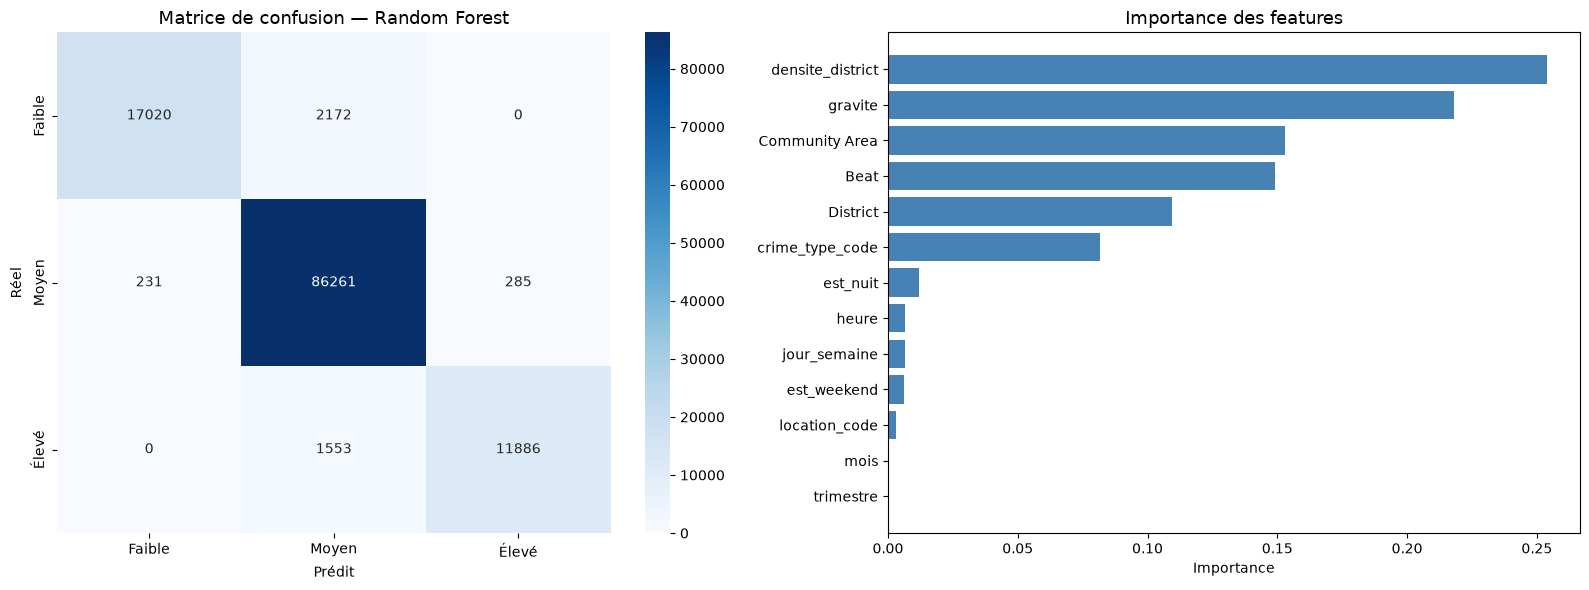

✅ Graphique sauvegardé


In [4]:
# ─── Cellule 4 : Visualisations du modèle ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Matrice de confusion ──────────────────────────────────────────
cm = confusion_matrix(y_test2, y_pred2)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Faible", "Moyen", "Élevé"],
            yticklabels=["Faible", "Moyen", "Élevé"])
axes[0].set_title("Matrice de confusion — Random Forest", fontsize=13)
axes[0].set_xlabel("Prédit")
axes[0].set_ylabel("Réel")

# ── Importance des features ───────────────────────────────────────
features_noms = FEATURES_CORRIGEES + ["densite_district"]
importances = pd.Series(rf2.feature_importances_, index=features_noms)
importances = importances.sort_values()
axes[1].barh(importances.index, importances.values, color="steelblue")
axes[1].set_title("Importance des features", fontsize=13)
axes[1].set_xlabel("Importance")

plt.tight_layout()
os.makedirs("../reports/figures", exist_ok=True)
plt.savefig("../reports/figures/model_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Graphique sauvegardé")

In [5]:
# ─── Cellule 5 : Sauvegarde du modèle ────────────────────────────
os.makedirs("../models", exist_ok=True)

joblib.dump(rf2, "../models/random_forest.pkl")
taille = os.path.getsize("../models/random_forest.pkl") / (1024*1024)
print(f"✅ Modèle sauvegardé : models/random_forest.pkl ({taille:.1f} Mo)")

# Sauvegarder aussi la liste des features
import json
with open("../models/features.json", "w") as f:
    json.dump(FEATURES_CORRIGEES + ["densite_district"], f)
print("✅ Features sauvegardées : models/features.json")

✅ Modèle sauvegardé : models/random_forest.pkl (6.9 Mo)
✅ Features sauvegardées : models/features.json


In [10]:
# ─── Cellule 6 : XGBoost ──────────────────────────────────────────
FEATURES_ML = [
    "heure", "jour_semaine", "mois", "trimestre",
    "est_weekend", "est_nuit",
    "District", "Community Area", "Beat",
    "crime_type_code", "Arrest", "Domestic"
]

df_model5 = df[FEATURES_ML].dropna()
df_model5 = df_model5.copy()

# Cible : frequence criminelle par Community Area (terciles)
freq_area = df.groupby("Community Area").size()
seuil_bas  = freq_area.quantile(0.33)
seuil_haut = freq_area.quantile(0.66)

def niveau_par_area(area):
    freq = freq_area.get(area, 0)
    if freq >= seuil_haut: return 2
    elif freq >= seuil_bas: return 1
    else: return 0

df_model5["cible"] = df_model5["Community Area"].apply(niveau_par_area)

X5 = df_model5[FEATURES_ML]
y5 = df_model5["cible"]

X_train5, X_test5, y_train5, y_test5 = train_test_split(
    X5, y5, test_size=0.2, random_state=42, stratify=y5
)

print(f"Distribution cible :")
print(f"  Faible (0) : {(y5==0).sum():,} ({(y5==0).mean()*100:.1f}%)")
print(f"  Moyen  (1) : {(y5==1).sum():,} ({(y5==1).mean()*100:.1f}%)")
print(f"  Eleve  (2) : {(y5==2).sum():,} ({(y5==2).mean()*100:.1f}%)")

# Random Forest
print("\nRandom Forest...")
rf5 = RandomForestClassifier(n_estimators=100, max_depth=12,
                              min_samples_leaf=20, random_state=42, n_jobs=-1)
rf5.fit(X_train5, y_train5)
y_pred_rf5 = rf5.predict(X_test5)
acc_rf5 = accuracy_score(y_test5, y_pred_rf5)
print(classification_report(y_test5, y_pred_rf5,
      target_names=["Faible","Moyen","Eleve"], zero_division=0))

# XGBoost
print("XGBoost...")
xgb5 = XGBClassifier(n_estimators=100, max_depth=8, learning_rate=0.1,
                      random_state=42, n_jobs=-1, verbosity=0, eval_metric="mlogloss")
xgb5.fit(X_train5, y_train5)
y_pred_xgb5 = xgb5.predict(X_test5)
acc_xgb5 = accuracy_score(y_test5, y_pred_xgb5)
print(classification_report(y_test5, y_pred_xgb5,
      target_names=["Faible","Moyen","Eleve"], zero_division=0))

print(f"Random Forest : {acc_rf5*100:.2f}%")
print(f"XGBoost       : {acc_xgb5*100:.2f}%")
meilleur = "XGBoost" if acc_xgb5 > acc_rf5 else "Random Forest"
print(f"Meilleur modele : {meilleur}")

# Sauvegarder
joblib.dump(rf5,  "../models/random_forest.pkl")
joblib.dump(xgb5, "../models/xgboost.pkl")
with open("../models/features.json", "w") as f:
    json.dump(FEATURES_ML, f)
print("\nModeles sauvegardes !")

Distribution cible :
  Faible (0) : 62,195 (10.4%)
  Moyen  (1) : 154,886 (25.9%)
  Eleve  (2) : 379,957 (63.6%)

Random Forest...
              precision    recall  f1-score   support

      Faible       1.00      0.65      0.79     12439
       Moyen       0.94      0.94      0.94     30977
       Eleve       0.95      1.00      0.97     75992

    accuracy                           0.95    119408
   macro avg       0.96      0.86      0.90    119408
weighted avg       0.95      0.95      0.94    119408

XGBoost...
              precision    recall  f1-score   support

      Faible       1.00      1.00      1.00     12439
       Moyen       1.00      1.00      1.00     30977
       Eleve       1.00      1.00      1.00     75992

    accuracy                           1.00    119408
   macro avg       1.00      1.00      1.00    119408
weighted avg       1.00      1.00      1.00    119408

Random Forest : 94.65%
XGBoost       : 100.00%
Meilleur modele : XGBoost

Modeles sauvegardes !
